In [1]:
import numpy as np
import matplotlib.pyplot as plt
def processSignals(ref, echo, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    return freq_response, s

def B_scan(dir, prefix, burst_len, num_steps):
    supposed_size = burst_len*num_steps
    s_list = []
    for i in range(14):
        #print(i)
        fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
        fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
        
        ref_samples = np.fromfile(fileName_ref, np.complex64)
        N = supposed_size - ref_samples.size
        #print(ref_samples.size,N)
        if N>=0:
            ref_samples = np.pad(ref_samples,(0,N),'constant')
        else:
            ref_samples = ref_samples[0:supposed_size]
        
        rx_samples = np.fromfile(fileName_rx, np.complex64)  
        N = supposed_size - rx_samples.size
        #print(rx_samples.size,N)
        if N>=0:
            rx_samples = np.pad(rx_samples,(0,N),'constant')
        else:
            rx_samples = rx_samples[0:supposed_size]
        
        f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)
        s_list.append(s)
    return np.stack(s_list, axis=0)   

(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)
(14, 128)


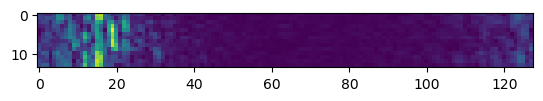

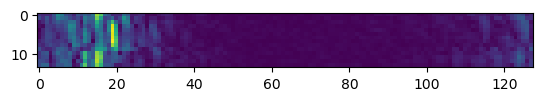

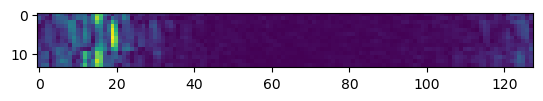

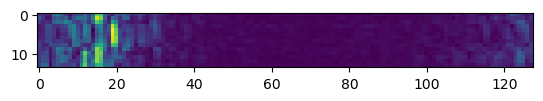

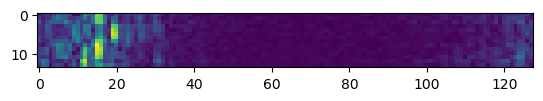

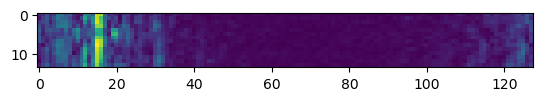

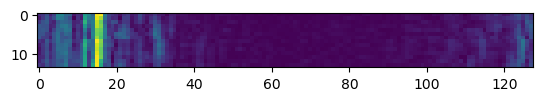

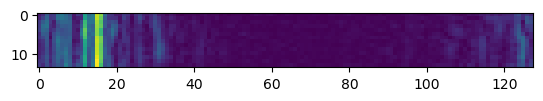

In [2]:
burst_len = 4096
num_steps = 128
supposed_size = burst_len*num_steps
b_scan_list = []
for dir_index in range(1,9):
    dir = '../gui/squarePlate/line' + str(dir_index)+'/'
    prefix = 'scan_raw'
    b_scan = B_scan(dir,prefix,burst_len,num_steps)
    plt.figure()
    plt.imshow(np.abs(b_scan))
    print(b_scan.shape)
    b_scan_list.append(b_scan)
#plt.imshow(np.abs(b_scan))
# plt.figure()
# plt.plot(np.angle(f))

# plt.figure()
# #plt.plot(10*np.log10(np.abs(s)))
# plt.plot((np.abs(s)))

In [90]:
for i in range(30):
    fileName = "b_scan_"+str(i)
    b_scan = B_scan('../gui/line2/','scan_raw',burst_len,num_steps)
    #plt.imshow(np.abs(b_scan))
    np.save(fileName,np.abs(b_scan))

In [105]:
b_scan_amp_list = []
for i in range(30):
    fileName = "b_scan_"+str(i)+".npy"
    b_scan_amp_list.append(np.load(fileName))

In [ ]:
i = 30
fileName = "b_scan_"+str(i)
b_scan_amp_list[i].shape
b_scan_amp_list[i][:,:]=0
plt.imshow(b_scan_amp_list[i])
np.save(fileName,b_scan_amp_list[i])

In [ ]:
c_scan = np.stack(b_scan_amp_list,axis=0)
c_scan_amp = np.copy(c_scan)
c_scan_amp[c_scan_amp<0.05]=0
c_scan_amp[:,:,0:19]=0
layer_list = []
for index in range(0,128):
    aLayer = c_scan_amp[:,:,index]
    aLayer [aLayer!=0]=index
    layer_list.append(aLayer)
layers = np.stack(layer_list,axis=0)
X = np.arange(0, 31, 1)
Y = np.arange(0, 30, 1)
X, Y = np.meshgrid(X, Y)
Z = layers.max(axis=0)
Z[Z==0]=np.NAN
# l1 = c_scan_amp[:,:,19]
# l1[l1!=0]=19
# l2 = c_scan_amp[:,:,20]
# l2[l2!=0]=20
# l3 = c_scan_amp[:,:,21]
# l3[l3!=0]=21
# l4 = c_scan_amp[:,:,22]
# l4[l4!=0]=22
# l = np.stack((l1,l2,l3,l4))
# l.shape
# Z = l.max(axis=0)
# Z[Z==0]=np.NAN

# Plot the surface.
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(X, Y, -Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

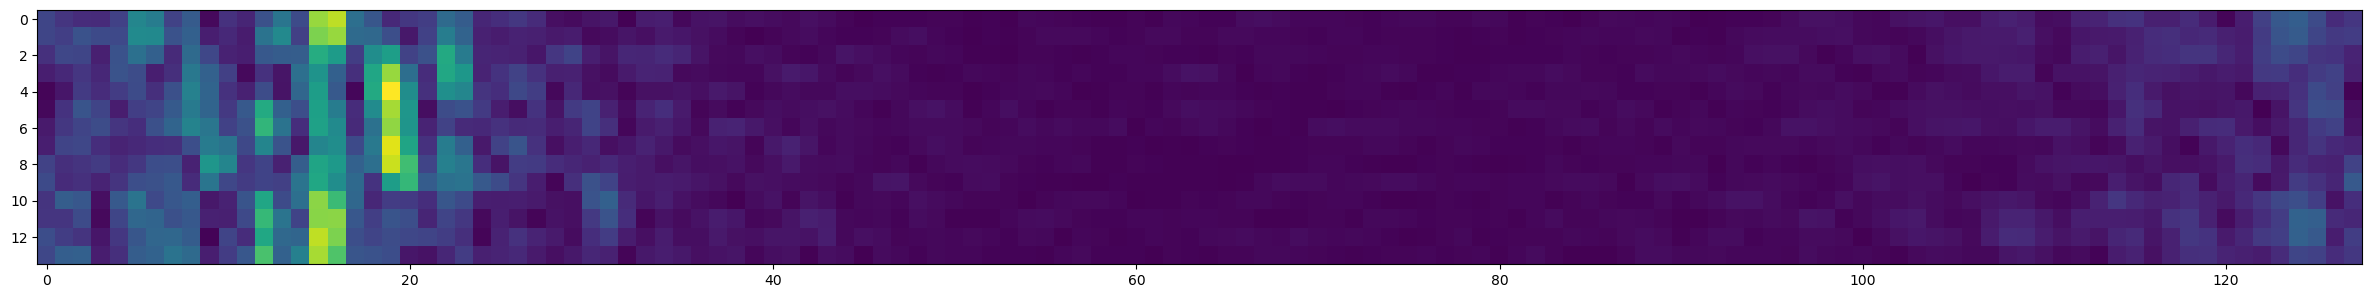

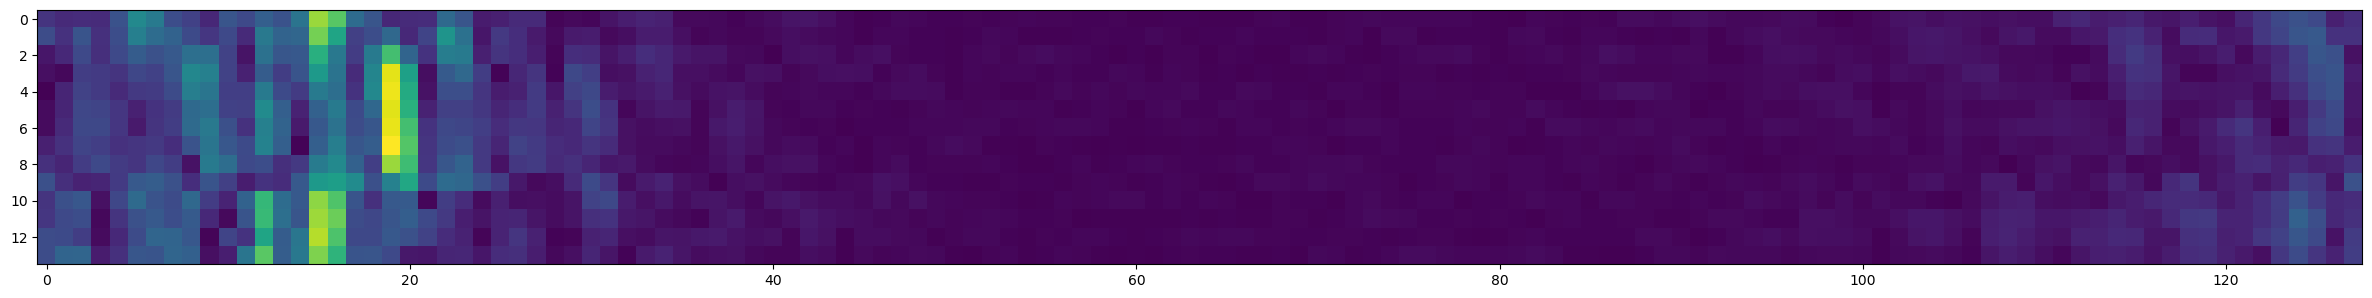

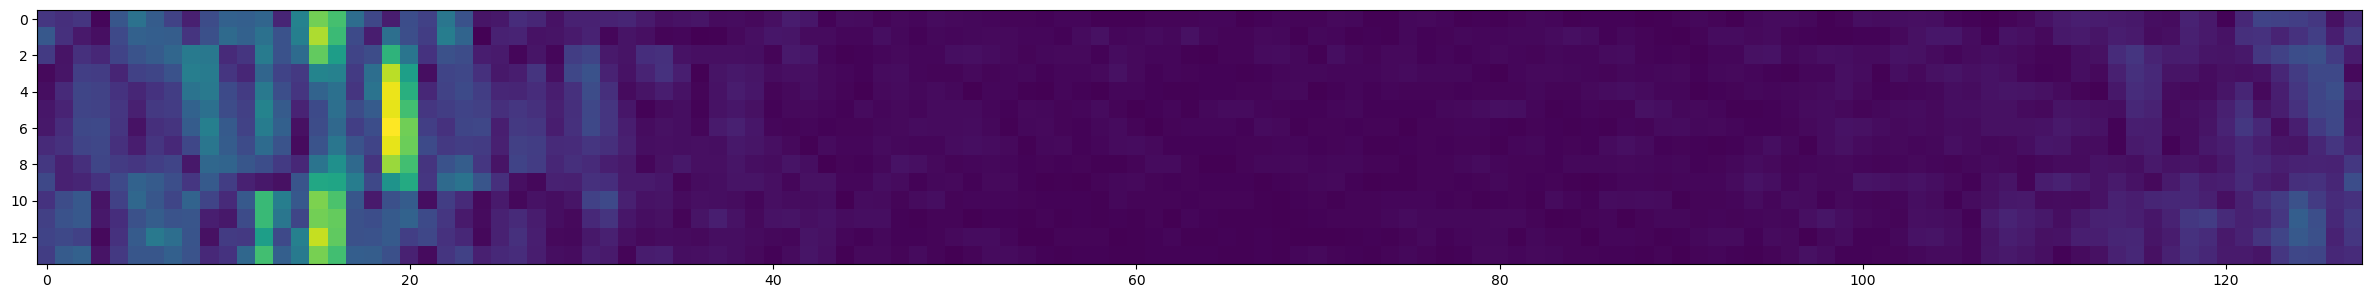

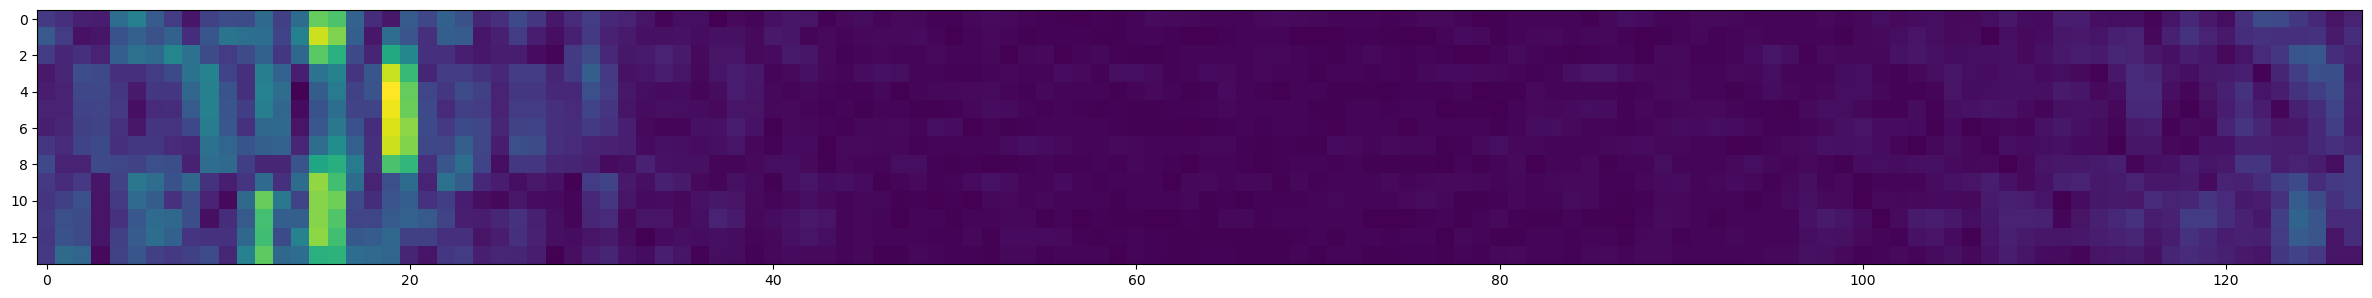

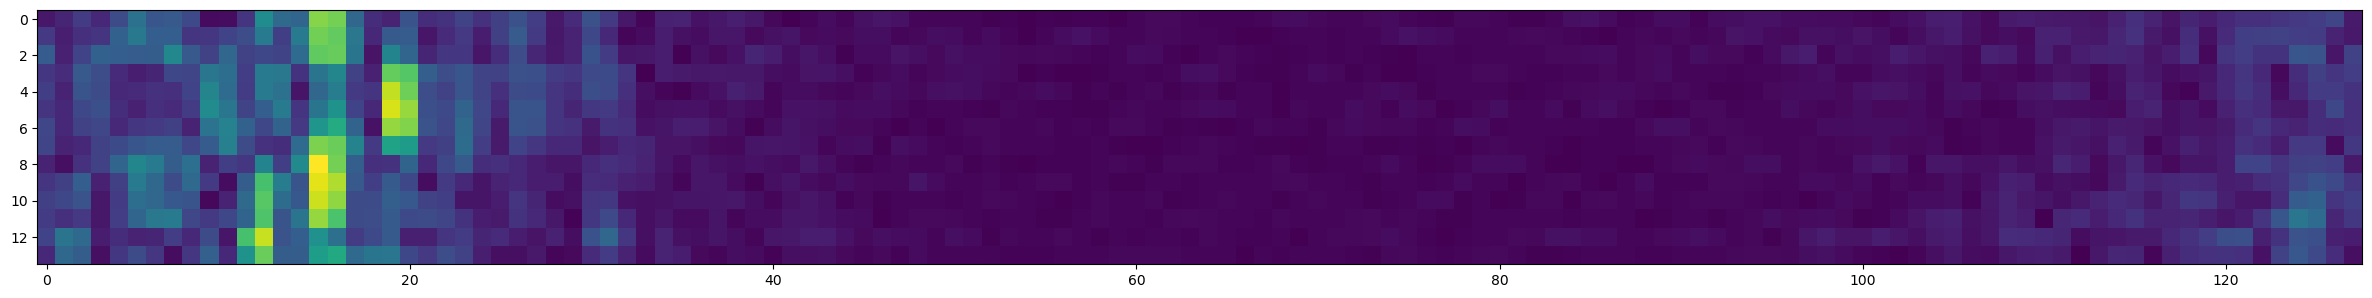

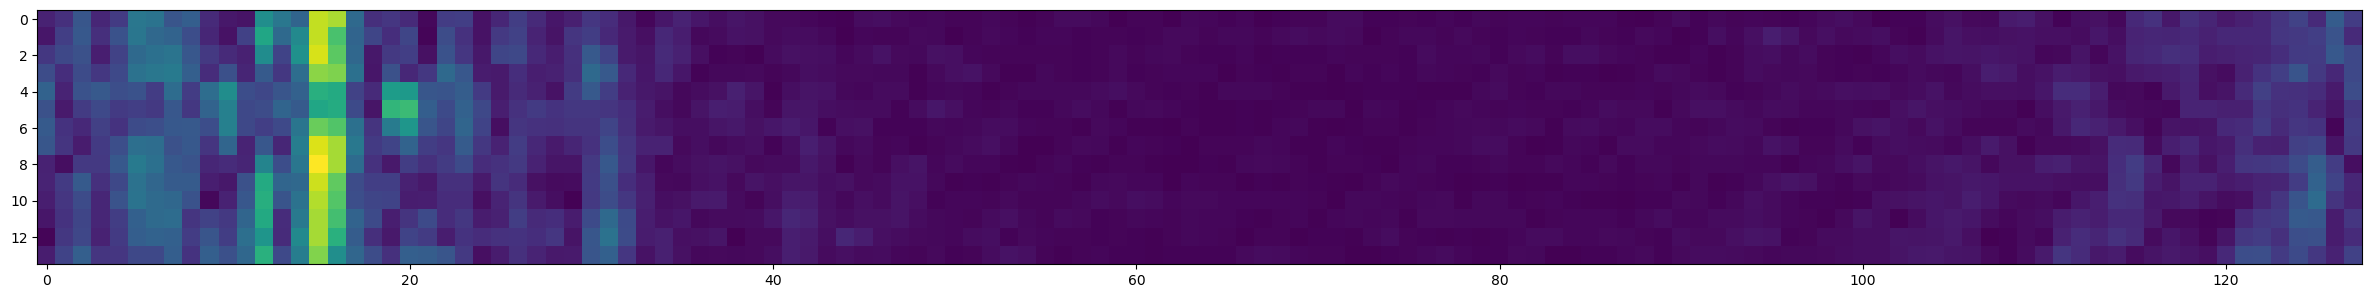

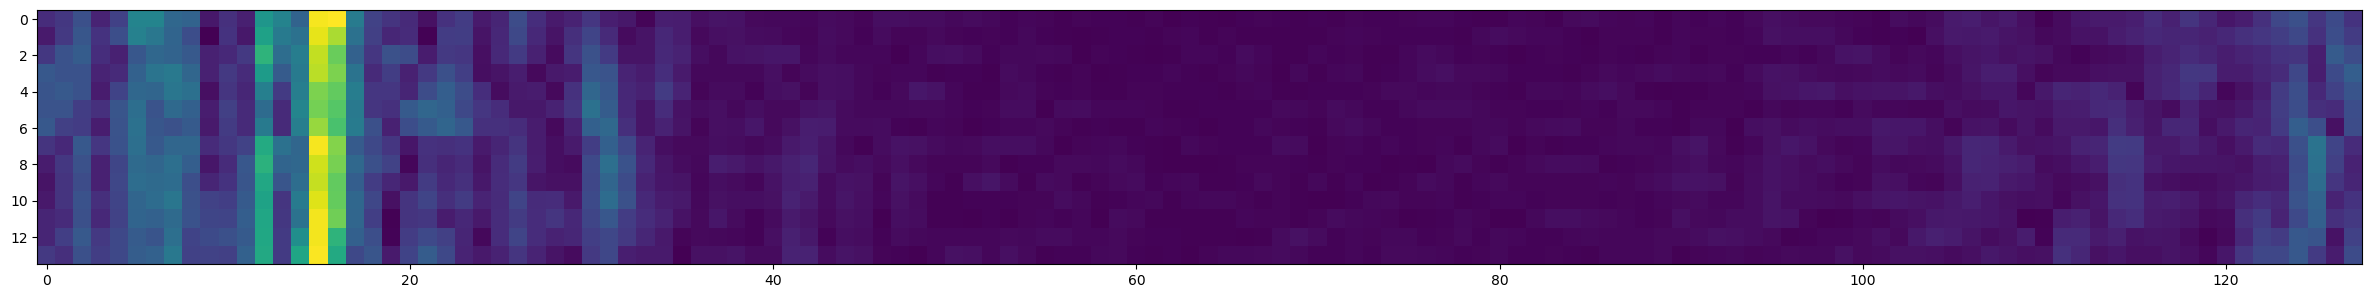

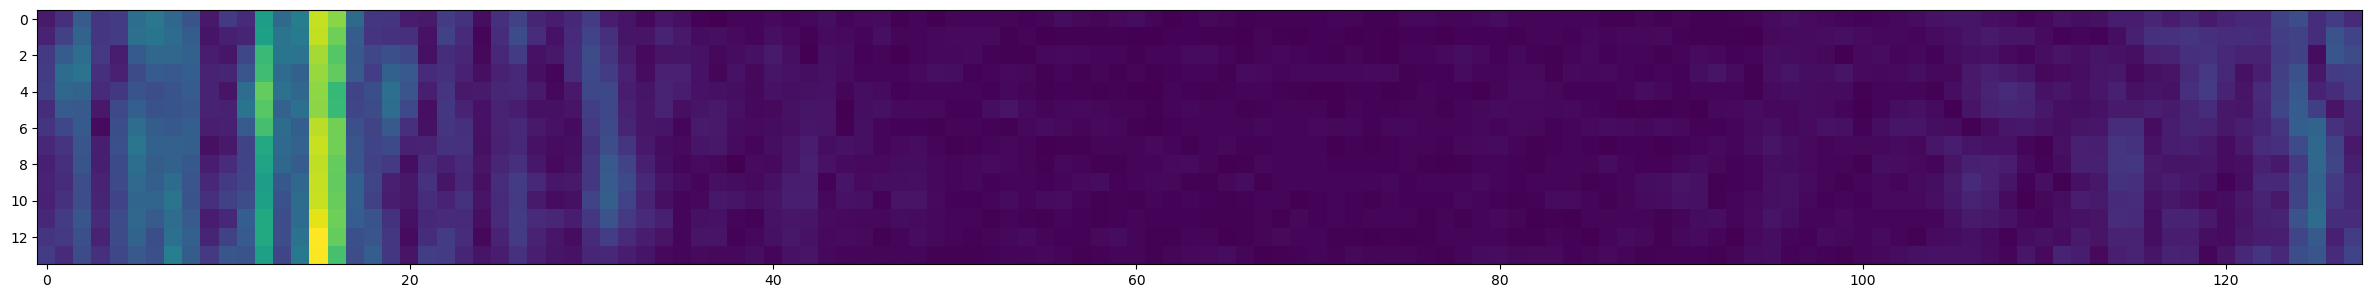

In [20]:
for i in range(8):
    plt.figure(figsize=(30,10))
    plt.imshow(np.abs(b_scan_list[i]))

In [15]:
c_scan = np.stack(b_scan_list,axis=0)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


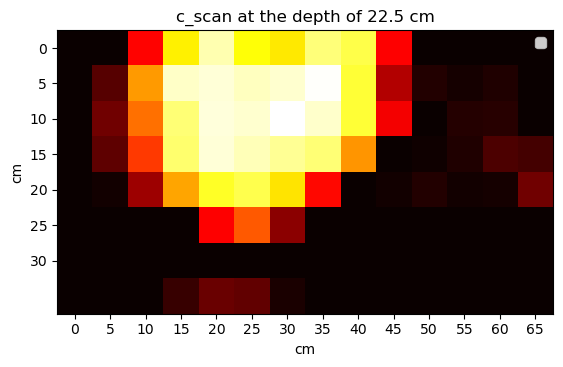

In [21]:
index = 19
plt.imshow(np.abs(c_scan[:,:,index]),cmap="hot",vmin=np.max(np.abs(c_scan))/4,vmax=np.max(np.abs(c_scan)))
plt.xlabel('cm')
plt.xticks(np.arange(0, 14, step=1), labels=[str(i*5) for i in range(14)])
plt.ylabel('cm')
plt.yticks(np.arange(0, 7, step=1), labels=[str(i*5) for i in range(7)])
depth = (index - 16)*7.5
plt.title("c_scan at the depth of " + str(depth) + " cm")
plt.legend()
plt.savefig('c_scan')

# plt.imshow(np.abs(c_scan[:,:,22]),cmap="hot",vmin=np.max(np.abs(c_scan))/4,vmax=np.max(np.abs(c_scan)))

In [47]:
c_scan_amp = np.abs(c_scan)

In [48]:
c_scan_amp[c_scan_amp<0.01]=0

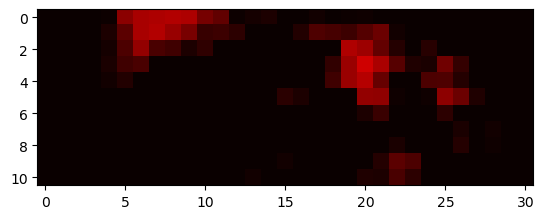

In [49]:
plt.imshow(c_scan_amp[:,:,21],cmap="hot",vmin=np.max(np.abs(c_scan))/4,vmax=np.max(np.abs(c_scan)))

In [50]:
l1 = c_scan_amp[:,:,19]
l1[l1!=0]=1
l2 = c_scan_amp[:,:,20]
l2[l2!=0]=2
l3 = c_scan_amp[:,:,21]
l3[l3!=0]=3
l4 = c_scan_amp[:,:,22]
l4[l4!=0]=4
l = np.stack((l1,l2,l3,l4))
l.shape

(4, 11, 31)

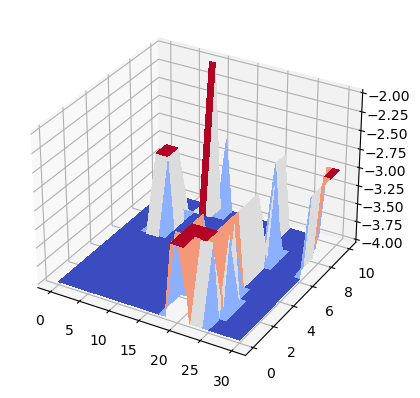

In [51]:
X = np.arange(0, 31, 1)
Y = np.arange(0, 11, 1)
X, Y = np.meshgrid(X, Y)
Z = l.max(axis=0)
Z[Z==0]=np.NAN
# Plot the surface.
from matplotlib import cm
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(X, Y, -Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

In [27]:
Z[Z==0]=np.NAN

In [130]:
ax.scatter(l1, y, -z, zdir='z', c= 'red')

(4, 31)

In [138]:
plt.scatter(l1)

TypeError: scatter() missing 1 required positional argument: 'y'

In [140]:
l1[:,1]

array([0., 0., 0., 0.])

In [142]:
import numpy
numpy.random.seed(29)
d = numpy.random.randint(0, 2, size=(3,3,3))
d

array([[[1, 1, 0],
        [1, 0, 0],
        [0, 1, 1]],

       [[0, 1, 1],
        [1, 0, 0],
        [0, 1, 1]],

       [[1, 1, 0],
        [0, 1, 0],
        [0, 0, 1]]])

In [143]:
d.shape

(3, 3, 3)

In [146]:
l1.nonzero()

(array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]),
 array([15, 16, 17, 18, 19, 20, 21, 22, 15, 16, 17, 18, 19, 20, 21, 22, 23,
        24, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28]))

In [168]:
l = np.stack((l1,l2,l3))
l.shape

(3, 4, 31)

In [151]:
x,y,z = l.nonzero()

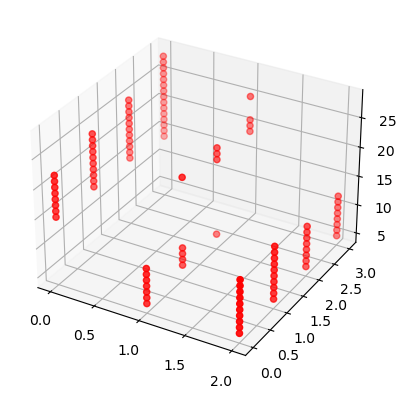

In [158]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, zdir='z', c= 'red')

In [155]:
from matplotlib import cm
ax.plot_surface(x, y, z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

ValueError: Argument Z must be 2-dimensional.

In [156]:
z

array([15, 16, 17, 18, 19, 20, 21, 22, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28,  5,  6,  7,  8,  9, 10, 11,
        6,  7,  8,  9, 21,  6, 19, 20, 21, 19, 20, 21, 25,  5,  6,  7,  8,
        9, 10, 11, 12, 13, 14,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14,  5,
        6,  7,  8,  9, 10, 11, 12,  5,  6,  7,  8,  9, 10, 11, 12])

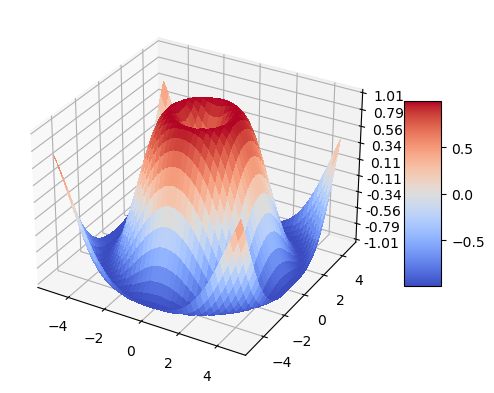

In [182]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Make data.
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(-1.01, 1.01)
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

In [185]:
Y

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.75, -4.75, -4.75, ..., -4.75, -4.75, -4.75],
       [-4.5 , -4.5 , -4.5 , ..., -4.5 , -4.5 , -4.5 ],
       ...,
       [ 4.25,  4.25,  4.25, ...,  4.25,  4.25,  4.25],
       [ 4.5 ,  4.5 ,  4.5 , ...,  4.5 ,  4.5 ,  4.5 ],
       [ 4.75,  4.75,  4.75, ...,  4.75,  4.75,  4.75]])